# Forecast the raw future abundance (single timepoint) of the lab microbiome — linear (OLS) baseline

Per-ASV **ordinary least squares (OLS)** on frozen-VAE latent features (`[mu ; last]` = deterministic
latent mean concatenated with the last observed abundance) as a linear baseline for one-step
raw-abundance forecasting, benchmarked against a persistence null and a fitted endpoint regression,
with leave-one-replicate-out (8-fold) CV across all media conditions and forecast horizons ΔT.
Per-fold results and paired truth/prediction arrays are exported to
`./target_forecast_OLS_regression_raw/`.

In [1]:
import os
import numpy as np
import torch
from torch import nn

import pandas as pd
import seaborn as sns
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

# Use GPU when available (frozen VAE encoder only; linear models run on CPU via scikit-learn)
device = "cuda:0" if torch.cuda.is_available() else "cpu"

# VAE Network
Same convolutional VAE as the target-forecast notebook (16 encoder channels, 3 conv layers,
kernel=3/stride=1/padding=1, symmetric decoder). We reuse the VAE that was pretrained per media
condition, and keep it frozen.

In [2]:
class VAE(nn.Module):

    def __init__(self, n_target, latent_dim):
        # Call parent model constructor and store hidden state variables.
        super().__init__()
        self.latent_dim = latent_dim
        self.n_target = n_target
        self.channels = 16

        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=self.n_target, out_channels=self.channels, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.Conv1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.Conv1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
        )

        self.mean_map = nn.Linear(self.channels * 30, self.latent_dim)

        self.std_map = nn.Linear(self.channels * 30, self.latent_dim)

        self.fc_decoder = nn.Sequential(
            nn.Linear(self.latent_dim, self.channels * 30),
            nn.LeakyReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1,
                               padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1,
                               padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose1d(in_channels=self.channels, out_channels=self.n_target, kernel_size=3, stride=1,
                               padding=1),
            nn.LeakyReLU()
        )

    def sample(self, mean, log_var):
        """Sample a given N(0,1) normal distribution given a mean and log of variance."""
        var = torch.exp(0.5 * log_var)
        eps = torch.randn_like(var)
        z = mean + var * eps
        return z

    def forward(self, X):
        pre_code = self.encoder(X)
        B, C, L = pre_code.shape
        flattened = pre_code.view(B, C * L)

        mu = self.mean_map(flattened)
        log_var = self.std_map(flattened)

        code = self.sample(mu, log_var)

        post_code = self.fc_decoder(code)

        X_hat = self.decoder(post_code.view(B, C, L))

        return X_hat, code, mu, log_var


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Curate the raw-abundance dataset
`X` = the 30-timepoint input segment (one channel per ASV). `y` = raw abundance at the single future timepoint `(30+delta_T-1, 30+delta_T, 30+delta_T+1)` relative to the segment start.
We keep the top `n_ref` ASVs (here 5).

In [3]:
def get_forecast_data_raw(sample: str, delta_T: int, n_ref: int):
    """
    Returns:
      Seg1: (8, n_segments, n_asv, 30)  input segments
      Y:    (8, n_segments, n_asv)      scalar target (raw future abundance at position 29 + delta_T,
                                        i.e. delta_T steps past the last observed point at position 29)
    """
    data_all = np.load(f"./lab_microbiome_datasets_CV/ranked/{sample}_ranked_relative.npy")
    n_reps = data_all.shape[0]
    timepoints = data_all.shape[1]
    n_asv = data_all.shape[2] if n_ref == -1 else n_ref

    T = 30
    # need timepoint i + T - 1 + delta_T <= timepoints - 2
    n_segments = timepoints - T - delta_T

    Seg1 = np.zeros((n_reps, n_segments, n_asv, T), dtype=data_all.dtype)
    Y = np.zeros((n_reps, n_segments, n_asv), dtype=data_all.dtype)

    for rep in range(n_reps):
        rep_data = data_all[rep]
        for i in range(n_segments):
            Seg1[rep, i] = rep_data[i: i + T, 0:n_asv].T
            Y[rep, i] = rep_data[i + T - 1 + delta_T, 0:n_asv]   # raw future point at position 29 + delta_T (delta_T past last obs)

    return Seg1, Y

## Per-ASV baselines (single condition)

On a single condition (Soil-A, ΔT=5) we compare four per-ASV models, each fit separately per ASV
with leave-one-replicate-out (8-fold) CV:

- **OLS (mu+last)** — ordinary least squares on the frozen-VAE features `[mu ; last]`.
- **OLS (raw window)** — ordinary least squares on the full raw 30-day input window (30 features,
  one per timepoint), with **no VAE embedding**.
- **endpoint** — a plain 1-D linear regression from the abundance at time *T* to the abundance at
  time *T+ΔT*; a *fitted/calibrated* persistence.
- **persistence** — the parameter-free null that carries the abundance at time *T* forward.

For all analyses we **exclude ASVs present in ≤ 2 of the 8 replicates** (`n_present ≤ 2`), where a
leave-one-replicate-out fit is ill-posed.

In [4]:
# ── Per-ASV baselines (Soil-A, ΔT=5): OLS[mu;last] vs OLS[raw 30d] vs endpoint vs persistence (LORO CV) ──
from sklearn.linear_model import LinearRegression

sample = "Soil-A"; delta_T = 5
targets = np.arange(5)
MIN_PRESENT = 3                          # exclude ASVs present in <= 2 replicates

Seg1_all, Y_all = get_forecast_data_raw(sample, delta_T, 5)
n_reps = Seg1_all.shape[0]
raw = np.load(f"./lab_microbiome_datasets_CV/ranked/{sample}_ranked_relative.npy")
present = {a: int((raw[:, :, a].max(axis=1) > 0.01).sum()) for a in targets}

Ec = int(np.ceil(np.loadtxt(f"./lab_microbiome_embedding_FUV_CV/{sample}_Ec.txt")[1, 0]))
vae = VAE(n_target=1, latent_dim=Ec).to(device)
vae.load_state_dict(torch.load(f"./vae_models_CV/{sample}_T1_E{Ec}_full.pth", weights_only=True))
vae.eval()

def encode_mu(vae, seg2d):
    """(N, 30) input segments -> (N, Ec) deterministic latent means."""
    x = torch.from_numpy(seg2d[:, None, :]).float().to(device)
    with torch.no_grad():
        pre = vae.encoder(x); B, C, L = pre.shape
        mu = vae.mean_map(pre.view(B, C * L))
    return mu.cpu().numpy()

feats = {(r, a): np.hstack([encode_mu(vae, Seg1_all[r][:, a, :]), Seg1_all[r][:, a, -1:]])
         for r in range(n_reps) for a in targets}

rows = []
for asv in targets:
    yt, mu_p, raw_p, endpoint_p, persist_p = [], [], [], [], []
    for test_rep in range(n_reps):
        train_reps = [r for r in range(n_reps) if r != test_rep]
        X_mu  = np.vstack([feats[(r, asv)] for r in train_reps])
        X_raw = np.vstack([Seg1_all[r][:, asv, :] for r in train_reps])      # full raw 30-day window
        xL_tr = np.vstack([Seg1_all[r][:, asv, -1:] for r in train_reps])    # abundance at time T only
        y_tr  = np.concatenate([Y_all[r][:, asv] for r in train_reps])
        ols_mu   = LinearRegression().fit(X_mu, y_tr)
        ols_raw  = LinearRegression().fit(X_raw, y_tr)
        endpoint = LinearRegression().fit(xL_tr, y_tr)
        mu_p.extend(ols_mu.predict(feats[(test_rep, asv)]))
        raw_p.extend(ols_raw.predict(Seg1_all[test_rep][:, asv, :]))
        endpoint_p.extend(endpoint.predict(Seg1_all[test_rep][:, asv, -1:]))
        persist_p.extend(Seg1_all[test_rep][:, asv, -1])
        yt.extend(Y_all[test_rep][:, asv])
    for model, p in (("OLS (mu+last)", mu_p), ("OLS (raw window)", raw_p),
                     ("endpoint", endpoint_p), ("persistence", persist_p)):
        rows.append(dict(asv=asv + 1, model=model, R2=r2_score(yt, p), n_present=present[asv]))

df_perasv = pd.DataFrame(rows)
excluded = sorted({a + 1 for a in targets if present[a] < MIN_PRESENT})
print("excluded ASVs (n_present <= 2):", excluded if excluded else "none")
df_perasv = df_perasv[df_perasv["n_present"] >= MIN_PRESENT]
print("mean R2 by model:")
print(df_perasv.groupby("model")["R2"].mean().round(3))
df_perasv.pivot(index="asv", columns="model", values="R2").round(3)

excluded ASVs (n_present <= 2): none
mean R2 by model:
model
OLS (mu+last)       0.717
OLS (raw window)    0.709
endpoint            0.752
persistence         0.703
Name: R2, dtype: float64


model,OLS (mu+last),OLS (raw window),endpoint,persistence
asv,,,,
1,0.719,0.728,0.724,0.678
2,0.695,0.636,0.676,0.604
3,0.769,0.760,0.775,0.799
4,0.724,0.750,0.727,0.650
5,0.678,0.670,0.860,0.786


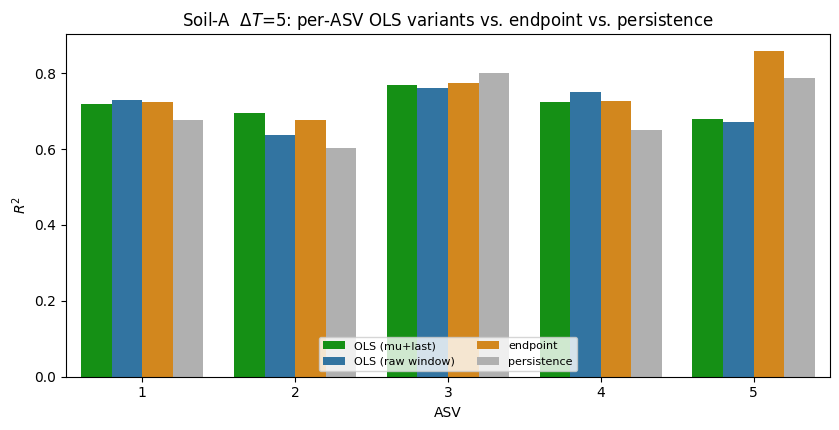

In [5]:
# ── Per-ASV R^2: OLS(mu+last) vs OLS(raw window) vs endpoint vs persistence (Soil-A, ΔT=5) ──
order = ["OLS (mu+last)", "OLS (raw window)", "endpoint", "persistence"]
palette = {"OLS (mu+last)": "#00A400", "OLS (raw window)": "#1F77B4",
           "endpoint": "#F08C00", "persistence": "#B0B0B0"}

fig, ax = plt.subplots(figsize=(8.5, 4.4))
sns.barplot(data=df_perasv, x="asv", y="R2", hue="model", hue_order=order, palette=palette, ax=ax)
ax.axhline(0, color="k", lw=0.7)
ax.set_xlabel("ASV"); ax.set_ylabel(r"$R^2$")
ax.set_title(rf"{sample}  $\Delta T$={delta_T}: per-ASV OLS variants vs. endpoint vs. persistence")
ax.legend(fontsize=8, ncol=2, loc="lower center")
fig.tight_layout()
# fig.savefig("./figures/raw_forecast_perASV_OLS_SoilA.png", dpi=300)  # figure-saving disabled for release
plt.show()

## Scale the per-ASV models across all media (Water / Soil): collective results

We apply four per-ASV models to **every media condition** (2 Water + 3 Soil) and every
ΔT ∈ {1, 2, 5, 10}, on identical leave-one-replicate-out (8-fold) folds:

- **OLS (mu+last)** — ordinary least squares on the `[mu ; last]` features (VAE embedding + endpoint).
- **OLS (raw window)** — ordinary least squares on the full raw 30-day input window (30 features,
  no embedding); the most flexible and therefore most overfit-prone linear model here.
- **endpoint** — 1-D linear regression from the abundance at time *T* to the abundance at *T+ΔT*.
- **persistence** — parameter-free null (prediction = abundance at time *T*).

For all analyses we **exclude ASVs present in ≤ 2 of the 8 replicates** (`n_present ≤ 2`).

The full per-fold record for every ASV (including the excluded ones, flagged by the `included`
column and `n_present`) is written to the per-media CSVs; the plots, summaries and paired `.npy`
arrays use only the included ASVs. Exports go to `./target_forecast_OLS_regression_raw/`.

In [6]:
# ── Per-ASV OLS(mu+last) vs OLS(raw window) vs endpoint vs persistence across ALL media & ΔT (identical LORO folds) ──
#    Linear models are plain OLS; analyses exclude ASVs present in <= 2 replicates.
#    Exports per-media R² CSVs (per-fold + pooled-per-ASV) and paired .npy files.
import os
from sklearn.linear_model import LinearRegression

OUT_DIR = "./target_forecast_OLS_regression_raw"
os.makedirs(OUT_DIR, exist_ok=True)

samples = ["Water-A", "Water-B", "Soil-A", "Soil-B", "Soil-C"]
DT = [1, 2, 5, 10]
n_asv = 5
targets = np.arange(n_asv)
PRESENCE_THR = 0.01                       # an ASV counts as "present" in a replicate if its max rel. abundance exceeds this
MIN_PRESENT = 3                           # analyses exclude ASVs present in <= 2 replicates (n_present < MIN_PRESENT)
PAIRED_SAMPLES = ("Water-A", "Soil-A")    # media for which we dump paired truth/prediction arrays
MODELS = ("OLS", "OLS_raw", "endpoint", "persistence")

def encode_mu(vae, seg2d):
    """(N, 30) input segments -> (N, Ec) deterministic latent means for a given VAE."""
    x = torch.from_numpy(seg2d[:, None, :]).float().to(device)
    with torch.no_grad():
        pre = vae.encoder(x); B, C, L = pre.shape
        mu = vae.mean_map(pre.view(B, C * L))
    return mu.cpu().numpy()

def n_present(sample, asv, thr=PRESENCE_THR):
    """Number of the 8 replicates in which the ASV is present (max relative abundance > thr)."""
    d = np.load(f"./lab_microbiome_datasets_CV/ranked/{sample}_ranked_relative.npy")
    return int((d[:, :, asv].max(axis=1) > thr).sum())

def fold_r2(y_true, y_pred):
    """Per-fold R²; NaN when the held-out ASV is absent/constant (R² undefined)."""
    return r2_score(y_true, y_pred) if (len(y_true) > 1 and np.ptp(y_true) > 0) else np.nan

rows = []          # pooled (collective) R² per (sample, ΔT, ASV) -> plots/summary
fold_rows = []     # per-fold R² (+ pooled-per-ASV R²) -> per-media CSVs (all ASVs, flagged)
paired = {s: [] for s in PAIRED_SAMPLES}

for sample in samples:
    env = "Water" if sample.startswith("Water") else "Soil"
    Ec = int(np.ceil(np.loadtxt(f"./lab_microbiome_embedding_FUV_CV/{sample}_Ec.txt")[1, 0]))
    vae = VAE(n_target=1, latent_dim=Ec).to(device)
    vae.load_state_dict(torch.load(f"./vae_models_CV/{sample}_T1_E{Ec}_full.pth", weights_only=True))
    vae.eval()
    present = {a: n_present(sample, a) for a in targets}

    for delta_T in DT:
        Seg1_all, Y_all = get_forecast_data_raw(sample, delta_T, n_asv)
        n_reps = Seg1_all.shape[0]
        feats = {(r, a): np.hstack([encode_mu(vae, Seg1_all[r][:, a, :]), Seg1_all[r][:, a, -1:]])
                 for r in range(n_reps) for a in targets}
        for asv in targets:
            inc = present[asv] >= MIN_PRESENT
            yt, pooled_pred = [], {m: [] for m in MODELS}
            asv_rows = []
            for test_rep in range(n_reps):
                train_reps = [r for r in range(n_reps) if r != test_rep]
                X_mu  = np.vstack([feats[(r, asv)] for r in train_reps])
                X_raw = np.vstack([Seg1_all[r][:, asv, :] for r in train_reps])      # full raw 30-day window
                xL_tr = np.vstack([Seg1_all[r][:, asv, -1:] for r in train_reps])    # abundance at time T only
                y_tr  = np.concatenate([Y_all[r][:, asv] for r in train_reps])
                ols_mu   = LinearRegression().fit(X_mu, y_tr)
                ols_raw  = LinearRegression().fit(X_raw, y_tr)
                endpoint = LinearRegression().fit(xL_tr, y_tr)
                y_true = Y_all[test_rep][:, asv]
                pred = {
                    "OLS":         ols_mu.predict(feats[(test_rep, asv)]),
                    "OLS_raw":     ols_raw.predict(Seg1_all[test_rep][:, asv, :]),
                    "endpoint":    endpoint.predict(Seg1_all[test_rep][:, asv, -1:]),
                    "persistence": Seg1_all[test_rep][:, asv, -1],                   # carry time T forward
                }
                for m in MODELS:
                    asv_rows.append(dict(sample=sample, env=env, delta_T=delta_T, asv=asv + 1,
                                         fold=test_rep + 1, model=m, R2=fold_r2(y_true, pred[m]),
                                         R2_pooled=np.nan, n_present=present[asv], included=inc))
                    pooled_pred[m].extend(pred[m])
                yt.extend(y_true)
                if sample in paired and inc:
                    for vals in zip(y_true, pred["OLS"], pred["OLS_raw"], pred["persistence"], pred["endpoint"]):
                        paired[sample].append((delta_T, asv + 1, test_rep + 1, *map(float, vals)))
            # pooled-per-ASV R² (all 8 folds concatenated) -- one value per model, stamped onto every fold row
            pooled = {m: r2_score(yt, pooled_pred[m]) for m in MODELS}
            for row in asv_rows:
                row["R2_pooled"] = pooled[row["model"]]
            fold_rows.extend(asv_rows)
            name = {"OLS": "OLS (mu+last)", "OLS_raw": "OLS (raw window)",
                    "endpoint": "endpoint", "persistence": "persistence"}
            for m in MODELS:
                rows.append(dict(sample=sample, env=env, delta_T=delta_T, asv=asv + 1,
                                 model=name[m], R2=pooled[m], n_present=present[asv], included=inc))
    print(f"{sample} sweep finished")

df_folds = pd.DataFrame(fold_rows)        # full record, all ASVs
df_all = pd.DataFrame(rows)                # pooled record, all ASVs

# per-media CSVs (all ASVs; `included` flags whether the ASV enters the analyses)
cols = ["sample", "env", "delta_T", "asv", "fold", "model", "R2", "R2_pooled", "n_present", "included"]
for sample in samples:
    (df_folds[df_folds["sample"] == sample][cols]
        .sort_values(["delta_T", "asv", "model", "fold"])
        .to_csv(f"{OUT_DIR}/{sample}_OLS_null_foldR2.csv", index=False))

# paired truth/prediction arrays (structured .npy) -- included ASVs only, first 5 ASVs of Water-A and Soil-A
paired_dtype = np.dtype([("delta_T", "i4"), ("asv", "i4"), ("fold", "i4"), ("y_true", "f8"),
                         ("y_OLS", "f8"), ("y_OLS_raw", "f8"), ("y_persistence", "f8"), ("y_endpoint", "f8")])
for sample in paired:
    np.save(f"{OUT_DIR}/{sample}_OLS_paired.npy", np.array(paired[sample], dtype=paired_dtype))

print("\nsaved to", OUT_DIR, ":", sorted(os.listdir(OUT_DIR)))

# ── exclude n_present <= 2 ASVs from all downstream analyses ──
excluded = (df_all[~df_all["included"]][["sample", "asv", "n_present"]]
            .drop_duplicates().sort_values(["sample", "asv"]))
print("\nExcluded ASVs (n_present <= 2), removed from analyses:")
print(excluded.to_string(index=False) if len(excluded) else "  none")
df_all = df_all[df_all["included"]].reset_index(drop=True)

def collective_summary(df):
    g = df.groupby(["sample", "model"])["R2"]
    cat = df[df.R2 < -1].groupby(["sample", "model"]).size()
    out = pd.DataFrame({"mean_R2": g.mean(), "median_R2": g.median(),
                        "off_scale_folds": cat}).fillna(0)
    out["off_scale_folds"] = out["off_scale_folds"].astype(int)
    return out.round(3)

print("\nCollective per-media summary (included ASVs only):")
print(collective_summary(df_all))
print("\nCollective median R2 by environment:")
print(df_all.groupby(["env", "model"])["R2"].median().round(3).unstack("model"))

Water-A sweep finished


Water-B sweep finished


Soil-A sweep finished


Soil-B sweep finished


Soil-C sweep finished

saved to ./target_forecast_OLS_regression_raw : ['Soil-A_OLS_null_foldR2.csv', 'Soil-A_OLS_paired.npy', 'Soil-B_OLS_null_foldR2.csv', 'Soil-C_OLS_null_foldR2.csv', 'Water-A_OLS_null_foldR2.csv', 'Water-A_OLS_paired.npy', 'Water-B_OLS_null_foldR2.csv']

Excluded ASVs (n_present <= 2), removed from analyses:
sample  asv  n_present
Soil-B    4          2
Soil-C    5          1

Collective per-media summary (included ASVs only):
                          mean_R2  median_R2  off_scale_folds
sample  model                                                
Soil-A  OLS (mu+last)       0.719      0.800                0
        OLS (raw window)    0.706      0.793                0
        endpoint            0.756      0.847                0
        persistence         0.652      0.812                0
Soil-B  OLS (mu+last)       0.584      0.677                0
        OLS (raw window)    0.582      0.670                0
        endpoint            0.560      0.655        

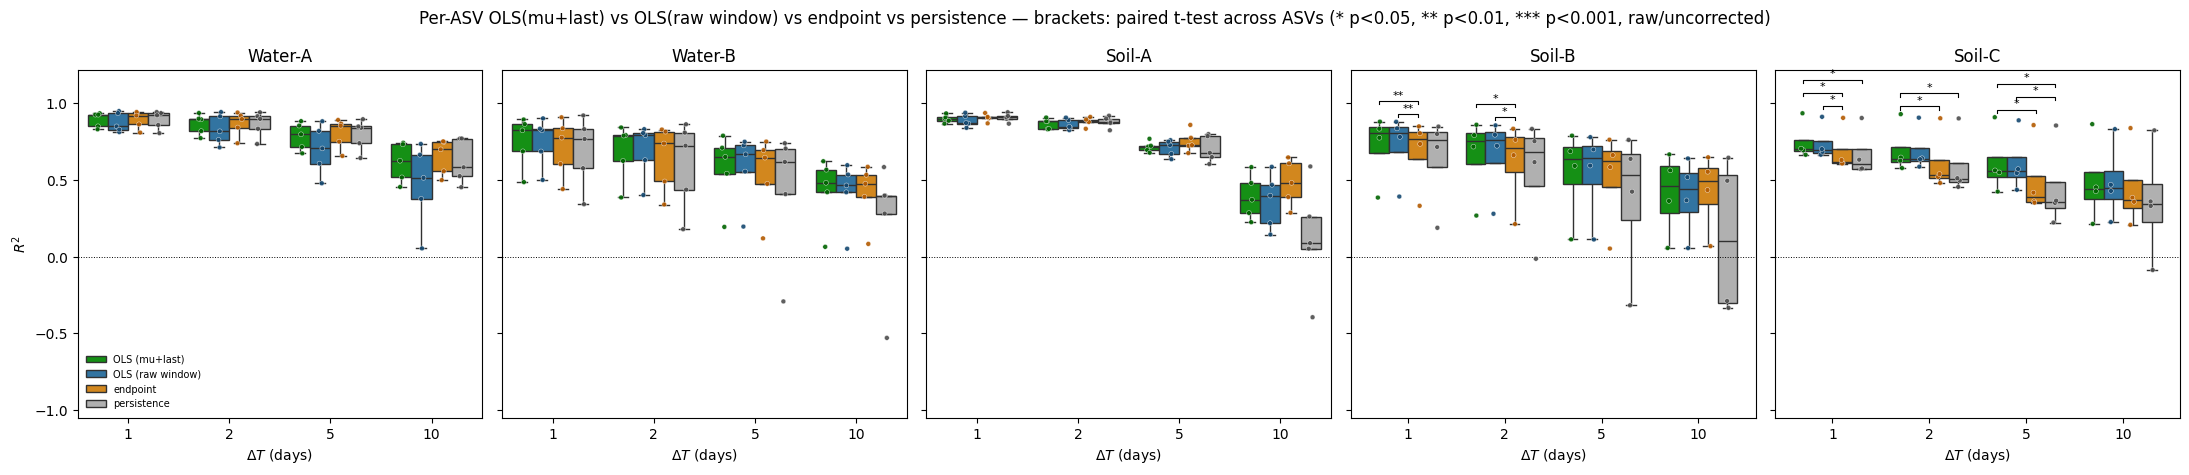

In [7]:
# ── Collective per-media view + paired-t significance brackets (raw p) across ΔT ──
from scipy.stats import ttest_rel
from itertools import combinations

order = ['OLS (mu+last)', 'OLS (raw window)', 'endpoint', 'persistence']
box_palette   = {"OLS (mu+last)": "#00A400", "OLS (raw window)": "#1F77B4",
                 "endpoint": "#F08C00", "persistence": "#B0B0B0"}
strip_palette = {"OLS (mu+last)": "#006400", "OLS (raw window)": "#144870",
                 "endpoint": "#B35A00", "persistence": "#4d4d4d"}
YLIM_LO = -1.05
STEP = 0.085
box_off = lambda h: 0.2 * (h - 1.5)      # x-offset of each dodged box (n=4 hues, width=0.8)

def sig_pairs(sample, dT):
    """Paired t-test (raw p) across included ASVs; returns (hueA, hueB, p) with raw p < 0.05."""
    piv = df_all[(df_all["sample"] == sample) & (df_all["delta_T"] == dT)].pivot_table(
        index="asv", columns="model", values="R2")
    res = []
    for A, B in combinations(order, 2):
        if A in piv.columns and B in piv.columns:
            d = piv[[A, B]].dropna()
            if len(d) >= 2:
                _, p = ttest_rel(d[A].values, d[B].values)
                if p < 0.05:
                    res.append((order.index(A), order.index(B), float(p)))
    return sorted(res, key=lambda z: abs(z[0] - z[1]))   # short brackets first (drawn lowest)

# headroom so brackets clear the boxes (shared y-axis)
tops = []
for s in samples:
    for dT in DT:
        pr = sig_pairs(s, dT)
        if pr:
            gmax = df_all[(df_all["sample"] == s) & (df_all["delta_T"] == dT)]["R2"].max()
            tops.append(max(min(gmax, 1.0) + 0.05, 0.5) + (len(pr) - 1) * STEP + 0.06)
YLIM_HI = max([1.0] + tops)

fig, axes = plt.subplots(1, 5, figsize=(22, 4.8), sharey=True)
for ax, sample in zip(axes, samples):
    sub = df_all[df_all["sample"] == sample]
    sns.boxplot(data=sub, x="delta_T", y="R2", hue="model", hue_order=order, palette=box_palette,
                showfliers=False, width=0.8, ax=ax)
    sns.stripplot(data=sub, x="delta_T", y="R2", hue="model", hue_order=order, dodge=True,
                  palette=strip_palette, size=3.5, alpha=0.9, linewidth=0.3, edgecolor="white", ax=ax)
    ax.axhline(0, color="k", lw=0.7, ls=":")
    ax.set_ylim(YLIM_LO, YLIM_HI)
    ax.set_title(sample); ax.set_xlabel(r"$\Delta T$ (days)")
    ax.set_ylabel(r"$R^2$" if sample == samples[0] else "")

    # significance brackets (paired t-test across ASVs, raw uncorrected p)
    for xc, dT in enumerate(DT):
        pairs = sig_pairs(sample, dT)
        if not pairs:
            continue
        gmax = sub[sub["delta_T"] == dT]["R2"].max()
        base = max(min(gmax, 1.0) + 0.05, 0.5)
        for k, (hA, hB, p) in enumerate(pairs):
            y = base + k * STEP
            xL, xR = xc + box_off(min(hA, hB)), xc + box_off(max(hA, hB))
            ax.plot([xL, xL, xR, xR], [y - 0.02, y, y, y - 0.02], lw=0.8, color="k", clip_on=False)
            star = "***" if p < 0.001 else "**" if p < 0.01 else "*"
            ax.text((xL + xR) / 2, y + 0.005, star, ha="center", va="bottom", fontsize=8)

    n_off = int((sub[sub.model.isin(order[:2])]["R2"] < YLIM_LO).sum())
    if n_off:
        ax.text(0.5, 0.02, f"{n_off} OLS fold(s) off-scale", transform=ax.transAxes,
                ha="center", va="bottom", fontsize=7, color="#8B0000")
    h, l = ax.get_legend_handles_labels()
    (ax.legend(h[:4], l[:4], loc="lower left", fontsize=7, frameon=False)
     if sample == samples[0] else ax.legend_.remove())

fig.suptitle('Per-ASV OLS(mu+last) vs OLS(raw window) vs endpoint vs persistence — brackets: paired t-test across ASVs '
             '(* p<0.05, ** p<0.01, *** p<0.001, raw/uncorrected)')
fig.tight_layout()
# fig.savefig('./figures/raw_forecast_OLS_vs_null_allmedia.png', dpi=300)  # figure-saving disabled for release
plt.show()

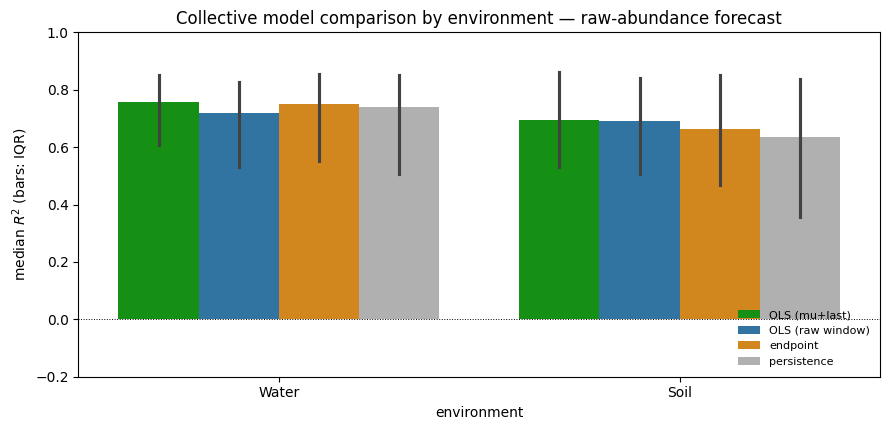

In [8]:
# ── Collective Water vs. Soil: median R^2 of the four models (robust, over media & ASVs) ──
order = ['OLS (mu+last)', 'OLS (raw window)', 'endpoint', 'persistence']
box_palette = {"OLS (mu+last)": "#00A400", "OLS (raw window)": "#1F77B4",
               "endpoint": "#F08C00", "persistence": "#B0B0B0"}
fig, ax = plt.subplots(figsize=(9, 4.4))
sns.barplot(data=df_all, x="env", y="R2", hue="model", hue_order=order,
            estimator=np.median, errorbar=("pi", 50), palette=box_palette, ax=ax)
ax.axhline(0, color="k", lw=0.7, ls=":")
ax.set_ylim(*(-0.2, 1.0))
ax.set_xlabel("environment"); ax.set_ylabel('median $R^2$ (bars: IQR)')
ax.set_title('Collective model comparison by environment — raw-abundance forecast')
ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.tight_layout()
# fig.savefig('./figures/raw_forecast_OLS_vs_null_byenv.png', dpi=300)  # figure-saving disabled for release
plt.show()

## Paired t-test on pooled R² across models, per (media × ΔT)

At **each fixed `(media, ΔT)`** we compare the models by pairing their per-ASV pooled R² across the
included ASVs (the ASV is the paired unit; each R² already aggregates the 8 folds). For every model
pair we run a paired t-test (`ttest_rel`) on $\Delta R^2 = R^2_A - R^2_B$ across ASVs and report the
**raw (uncorrected) p-value**.

**Caveats:** only 4–5 ASVs per condition, so each test has n=4–5 — low power, and the normality of
4–5 paired differences is uncheckable. The p-values are **not** corrected for multiple comparisons, so
across the 20 `(media × ΔT)` conditions × 6 model pairs a handful of p < 0.05 are expected by chance;
read `mean_dR2` and `wins_A` as the primary effect/direction and treat isolated small p's cautiously.
ASVs are also compositional (not fully independent).

In [9]:
# ── Paired t-test on pooled R² ACROSS MODELS, per (media, ΔT); ASV = paired unit; raw (uncorrected) p ──
from scipy.stats import ttest_rel
from itertools import combinations

model_order = ["OLS (mu+last)", "OLS (raw window)", "endpoint", "persistence"]
short = {"OLS (mu+last)": "OLS_mu", "OLS (raw window)": "OLS_raw", "endpoint": "endpoint", "persistence": "persist"}

recs = []
for (sample, dT), sub in df_all.groupby(["sample", "delta_T"]):   # df_all is included ASVs only
    piv = sub.pivot_table(index="asv", columns="model", values="R2")
    for A, B in combinations(model_order, 2):
        d = piv[[A, B]].dropna(); a, b = d[A].values, d[B].values
        t, p = ttest_rel(a, b) if len(a) >= 2 else (np.nan, np.nan)
        recs.append(dict(sample=sample, delta_T=dT, n_asv=len(a), model_A=short[A], model_B=short[B],
                         mean_dR2=round(float((a - b).mean()), 3),
                         t=(round(float(t), 2) if len(a) >= 2 else np.nan),
                         p_value=float(p), wins_A=f"{int((a > b).sum())}/{len(a)}"))

tt = pd.DataFrame(recs)
tt["sig.05"] = tt["p_value"] < 0.05

show = tt.copy()
show["p_value"] = show["p_value"].map(lambda v: f"{v:.2e}")
pd.set_option("display.width", 220, "display.max_columns", 40, "display.max_rows", None)
print("Paired t-test on pooled R² per (media, ΔT); paired across ASVs; raw p (uncorrected); mean_dR2 = R²_A - R²_B (+ => A better)\n")
print(show[["sample", "delta_T", "n_asv", "model_A", "model_B", "mean_dR2", "t", "p_value", "sig.05", "wins_A"]].to_string(index=False))

print(f"\nModel pairs with raw p < 0.05: {int(tt['sig.05'].sum())} of {len(tt)} tests")
if tt["sig.05"].any():
    print(tt[tt["sig.05"]][["sample", "delta_T", "model_A", "model_B", "mean_dR2", "p_value"]].to_string(index=False))

Paired t-test on pooled R² per (media, ΔT); paired across ASVs; raw p (uncorrected); mean_dR2 = R²_A - R²_B (+ => A better)

 sample  delta_T  n_asv  model_A  model_B  mean_dR2     t  p_value  sig.05 wins_A
 Soil-A        1      5   OLS_mu  OLS_raw     0.012  0.83 4.55e-01   False    2/5
 Soil-A        1      5   OLS_mu endpoint    -0.006 -1.48 2.12e-01   False    0/5
 Soil-A        1      5   OLS_mu  persist    -0.007 -1.20 2.95e-01   False    3/5
 Soil-A        1      5  OLS_raw endpoint    -0.019 -1.20 2.96e-01   False    2/5
 Soil-A        1      5  OLS_raw  persist    -0.020 -1.23 2.86e-01   False    2/5
 Soil-A        1      5 endpoint  persist    -0.001 -0.44 6.80e-01   False    3/5
 Soil-A        2      5   OLS_mu  OLS_raw     0.005  0.40 7.10e-01   False    2/5
 Soil-A        2      5   OLS_mu endpoint    -0.013 -1.11 3.30e-01   False    1/5
 Soil-A        2      5   OLS_mu  persist    -0.012 -0.81 4.65e-01   False    3/5
 Soil-A        2      5  OLS_raw endpoint    -0.018 -1.